# Introduction to Statistical Learning

This file is about the applied exercises and others practices that could be userfull

# Analise de dados

In [5]:
# Importing libraries
import pandas as pd
from scipy import stats
import seaborn as sns
from datetime import datetime
import matplotlib.pyplot as plt
import numpy as np
import kagglehub
from sklearn import linear_model
from sklearn.model_selection import train_test_split
import statsmodels.api as sm

### Options


In [6]:
# Options
pd.set_option("display.max_columns", 999)
pd.set_option("display.max_rows", 999)
plt.rcParams.update({'figure.autolayout': True})


# Load and wrangling Dataset

In [7]:

# Load database

path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")

print("Path to dataset files:", path)

customers = pd.read_csv('C:/Users/felip/.cache/kagglehub/datasets/olistbr/brazilian-ecommerce/versions/2/olist_customers_dataset.csv')
geolocation = pd.read_csv('C:/Users/felip/.cache/kagglehub/datasets/olistbr/brazilian-ecommerce/versions/2/olist_geolocation_dataset.csv')
items = pd.read_csv('C:/Users/felip/.cache/kagglehub/datasets/olistbr/brazilian-ecommerce/versions/2/olist_order_items_dataset.csv')
payments = pd.read_csv('C:/Users/felip/.cache/kagglehub/datasets/olistbr/brazilian-ecommerce/versions/2/olist_order_payments_dataset.csv')
reviews = pd.read_csv('C:/Users/felip/.cache/kagglehub/datasets/olistbr/brazilian-ecommerce/versions/2/olist_order_reviews_dataset.csv')
orders = pd.read_csv('C:/Users/felip/.cache/kagglehub/datasets/olistbr/brazilian-ecommerce/versions/2/olist_orders_dataset.csv')
products = pd.read_csv('C:/Users/felip/.cache/kagglehub/datasets/olistbr/brazilian-ecommerce/versions/2/olist_products_dataset.csv')
sellers = pd.read_csv('C:/Users/felip/.cache/kagglehub/datasets/olistbr/brazilian-ecommerce/versions/2/olist_sellers_dataset.csv')
category = pd.read_csv('C:/Users/felip/.cache/kagglehub/datasets/olistbr/brazilian-ecommerce/versions/2/product_category_name_translation.csv')

dfs_list = [customers, geolocation, items, payments, reviews, orders, products, sellers, category]

print('customers',customers.columns, '\n',
'geolocation', geolocation.columns, '\n',
'items', items.columns, '\n',
'payments', payments.columns, '\n',
'reviews',reviews.columns, '\n',
'orders',orders.columns, '\n',
'products',products.columns, '\n',
'sellers',sellers.columns, '\n',
'category',category.columns)

income_UF = pd.read_excel('Tabela 5436.xlsx', header=0, names=['UF','mean_income'], skiprows=4, skipfooter=1)
UF_dic = {'Rondônia':'RO', 'Acre':'AC', 'Amazonas':'AM', 'Roraima':'RR','Pará':'PA', \
    'Amapá':'AP', 'Tocantins' :'TO',
    'Maranhão':'MA', 'Piauí':'PI', 'Ceará':'CE', 
    'Rio Grande do Norte':'RN', 'Paraíba':'PB', 'Pernambuco':'PE', 'Alagoas':'AL', 
    'Sergipe':'SE', 'Bahia':'BA', 'Minas Gerais':'MG', 
    'Espírito Santo':'ES', 'Rio de Janeiro':'RJ', 
    'São Paulo':'SP', 'Paraná':'PR', 'Santa Catarina':'SC', 'Rio Grande do Sul':'RS', 
    'Mato Grosso do Sul':'MS', 'Mato Grosso':'MT', 'Goiás':'GO', 'Distrito Federal':'DF'}

income_UF['short_UF'] = income_UF['UF'].map(UF_dic)
month_str = ['Jan','Fev','Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']
month_int = ['01','02','03','04','05','06','07','08','09','10','11','12']

month_dict = dict(zip(month_str,month_int))
month_dict_inv = dict(zip(month_int, month_str))
category_dict = {'cama_mesa_banho':'itens de casa e móveis - não elétricos',  \
    'beleza_saúde':'higiene, pergumaria e afins', \
    'esporte_lazer':'áudio, vídeo, música, brinquedos -  hobbies e lazer', \
    'moveis_decoracao':'itens de casa e móveis - não elétricos', \
    'informatica_acessorios':'informática e games', \
    'utilidades_domesticas':'itens de casa e móveis - não elétricos', \
    'relogios_presentes':'vestuários, calçados, acessórios e presentes', \
    'telefonia':'eletrodomésticos e eletrônicos', \
    'ferramentas_jardim':'ferramentas em geral, construção e afins', 
    'automotivo':'automotivo', 
    'brinquedos':'áudio, vídeo, música, brinquedos -  hobbies e lazer', 
    'cool_stuff':'áudio, vídeo, música, brinquedos -  hobbies e lazer', 
    'perfumaria':'higiene, pergumaria e afins', 
    'bebes':'higiene, pergumaria e afins', 
    'eletronicos':'eletrodomésticos e eletrônicos', 
    'papelaria':'papelaria e livraria', 
    'fashion_bolsas_e_acessorios':'vestuários, calçados, acessórios e presentes', 
    'pet_shop':'outros', 
    'moveis_escritorio':'itens de casa e móveis - não elétricos', 
    'consoles_games':'informática e games',
    'malas_acessorios':'vestuários, calçados, acessórios e presentes', 
    'construcao_ferramentas_construcao':'ferramentas em geral, construção e afins', 
    'eletrodomesticos':'itens de casa e móveis - não elétricos', 
    'instrumentos_musicais':'áudio, vídeo, música, brinquedos -  hobbies e lazer', 
    'eletroportateis':'eletrodomésticos e eletrônicos', 
    'casa_construcao':'ferramentas em geral, construção e afins', 
    'livros_interesse_geral':'papelaria e livraria', 
    'moveis_sala':'itens de casa e móveis - não elétricos', 
    'alimentos':'alimentos e bebidas e outros comestíveis', 
    'casa_conforto':'itens de casa e móveis - não elétricos', 
    'bebidas':'alimentos e bebidas e outros comestíveis', 
    'audio':'áudio, vídeo, música, brinquedos -  hobbies e lazer', 
    'market_place':'outros', 
    'construcao_ferramentas_iluminacao':'ferramentas em geral, construção e afins',
    'climatizacao':'eletrodomésticos e eletrônicos', 
    'moveis_cozinha_area_de_servico_jantar_e_jardim':'itens de casa e móveis - não elétricos',
    'alimentos_bebidas':'alimentos e bebidas e outros comestíveis', 
    'fashion_calcados':'vestuários, calçados, acessórios e presentes', 
    'telefonia_fixa':'eletrodomésticos e eletrônicos',
    'industria_comercio_e_negocios':'outros', 
    'livros_tecnicos':'papelaria e livraria',
    'eletrodomesticos_2':'eletrodomésticos e eletrônicos', 
    'agro_industria_e_comercio':'outros',
    'construcao_ferramentas_jardim':'ferramentas em geral, construção e afins', 
    'pcs':'informática e games',
    'artes':'áudio, vídeo, música, brinquedos -  hobbies e lazer',
    'sinalizacao_e_seguranca':'outros', 
    'construcao_ferramentas_seguranca':'ferramentas em geral, construção e afins',
    'artigos_de_natal':'itens de casa e móveis - não elétricos', 
    'fashion_roupa_masculina':'vestuários, calçados, acessórios e presentes',
    'fashion_underwear_e_moda_praia':'vestuários, calçados, acessórios e presentes',
    'moveis_quarto':'itens de casa e móveis - não elétricos',
    'construcao_ferramentas_ferramentas':'ferramentas em geral, construção e afins', 
    'tablets_impressao_imagem':'eletrodomésticos e eletrônicos',
    'portateis_casa_forno_e_cafe':'eletrodomésticos e eletrônicos', 
    'cine_foto':'áudio, vídeo, música, brinquedos -  hobbies e lazer', 
    'dvds_blu_ray':'áudio, vídeo, música, brinquedos -  hobbies e lazer',
    'livros_importados':'papelaria e livraria', 
    'fashion_roupa_feminina':'vestuários, calçados, acessórios e presentes', 
    'artigos_de_festas':'outros',
    'moveis_colchao_e_estofado':'itens de casa e móveis - não elétricos', 
    'musica':'áudio, vídeo, música, brinquedos -  hobbies e lazer', 
    'fraldas_higiene':'higiene, pergumaria e afins', 
    'flores':'itens de casa e móveis - não elétricos',
    'casa_conforto_2':'itens de casa e móveis - não elétricos', 
    'fashion_esporte':'vestuários, calçados, acessórios e presentes', 
    'artes_e_artesanato':'áudio, vídeo, música, brinquedos -  hobbies e lazer',
    'la_cuisine':'itens de casa e móveis - não elétricos', 
    'portateis_cozinha_e_preparadores_de_alimentos':'eletrodomésticos e eletrônicos',
    'cds_dvds_musicais':'áudio, vídeo, música, brinquedos -  hobbies e lazer', 
    'pc_gamer':'informática e games',
    'fashion_roupa_infanto_juvenil':'vestuários, calçados, acessórios e presentes',
    'seguros_e_servicos':'outros'}

# Joinning dataframes

df = pd.merge(right=customers, left=orders, on='customer_id', suffixes=(None,'_r'))
df = pd.merge(left=df, right=orders, on='order_id', suffixes=(None,'_r'))
df = pd.merge(left=df, right=payments, on='order_id', suffixes=(None,'_r'))
df = pd.merge(left=df, right=items , on='order_id', suffixes=(None,'_r'))
df = pd.merge(left=df, right=products, on='product_id', suffixes=(None,'_r'))
df = pd.merge(left=df, right=income_UF, left_on='customer_state',\
     right_on='short_UF', suffixes=(None,'_r'))


df['product_category_name'] = df['product_category_name'].map(category_dict)
print(df.columns)
print(df.shape)

# Filtering
df.drop(columns=df.filter(regex='_r', axis=1).columns, inplace=True)
df.set_index('customer_id', inplace=True)

# Grouping by costumers Id

df_cust_group = df[['customer_unique_id','payment_value','freight_value']].\
    groupby(by='customer_unique_id').\
    agg(payment_value_sum=('payment_value','sum'),
    payment_value_mean = ('payment_value','mean'),
    freight_value_sum=('freight_value','sum'),
    freight_value_mean=('freight_value','mean')).reset_index()

# add other information about the customers
df_cust_group = df_cust_group.merge(right=customers[['customer_unique_id', \
    'customer_state']],
    on='customer_unique_id', how='left')

df_cust_group.duplicated().value_counts()

df_cust_group = df_cust_group.merge(right=income_UF, \
    left_on='customer_state', right_on='short_UF', how='left')

df_cust_group.duplicated().value_counts()

# AJustment of data
df['ano'] = df['order_purchase_timestamp'].str.slice(0,4,1)
df['mes'] = df['order_purchase_timestamp'].str.slice(5,7,1)
# Grouping by category

df_category_gp = df.groupby(['ano','product_category_name']).\
    agg(receita =('payment_value','sum'),
    receita_media = ('payment_value', 'mean'),
    preco_medio = ('price', 'mean')).reset_index()

# Creating timeseries
df_ts_gp = df.copy()
df_ts_gp.reset_index(inplace=True)
df_ts_gp['order_purchase_timestamp'] = df_ts_gp['order_purchase_timestamp'].str.slice(0,7,1)
df_ts_gp = df_ts_gp[['order_status','payment_value', 'order_purchase_timestamp']]
df_ts_gp = df_ts_gp.groupby(['order_status','order_purchase_timestamp']).sum(numeric_only=True)
df_ts_gp.reset_index(inplace=True)
df_ts_gp.set_index('order_purchase_timestamp', inplace=True)
df_ts_gp_pvt = df_ts_gp.pivot(columns = 'order_status', values = 'payment_value')




Path to dataset files: C:\Users\felip\.cache\kagglehub\datasets\olistbr\brazilian-ecommerce\versions\2
customers Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='object') 
 geolocation Index(['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng',
       'geolocation_city', 'geolocation_state'],
      dtype='object') 
 items Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value'],
      dtype='object') 
 payments Index(['order_id', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value'],
      dtype='object') 
 reviews Index(['review_id', 'order_id', 'review_score', 'review_comment_title',
       'review_comment_message', 'review_creation_date',
       'review_answer_timestamp'],
      dtype='object') 
 orders Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_app

# Analisys

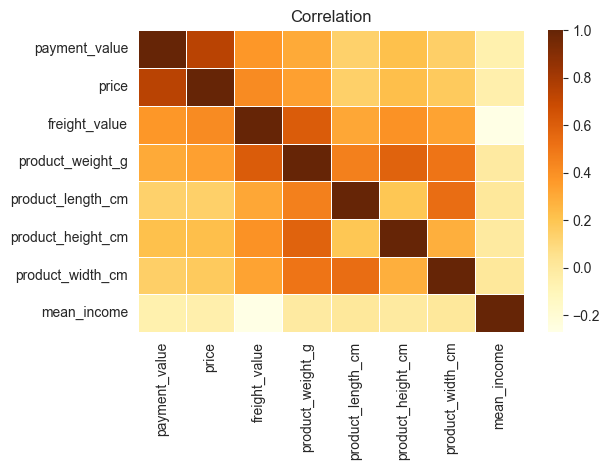

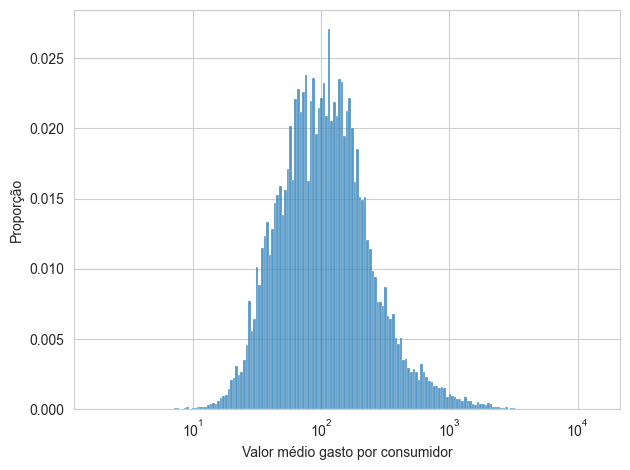

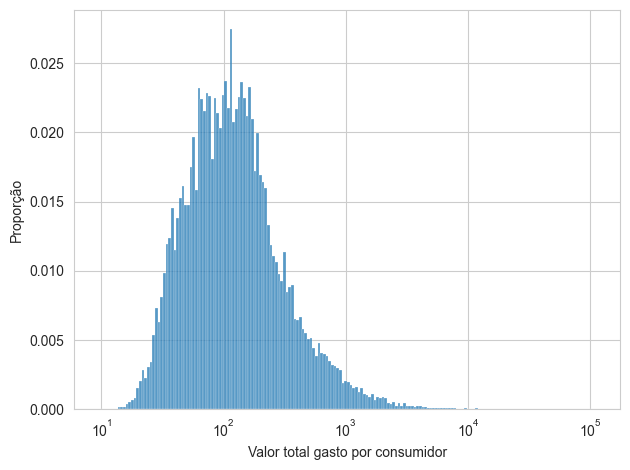

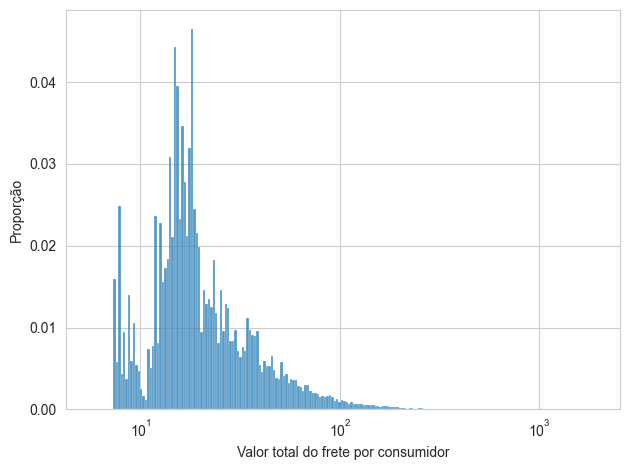

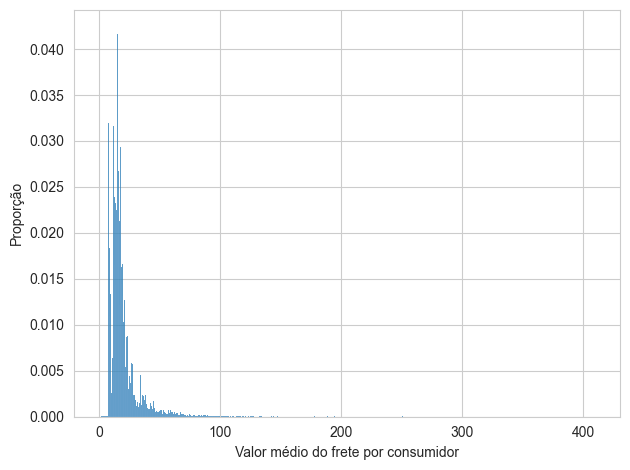

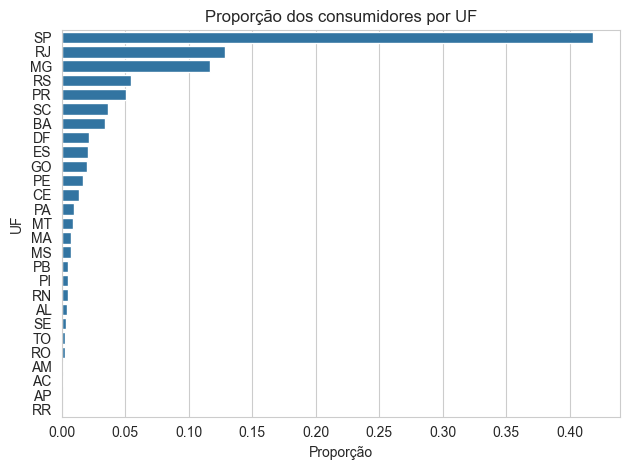

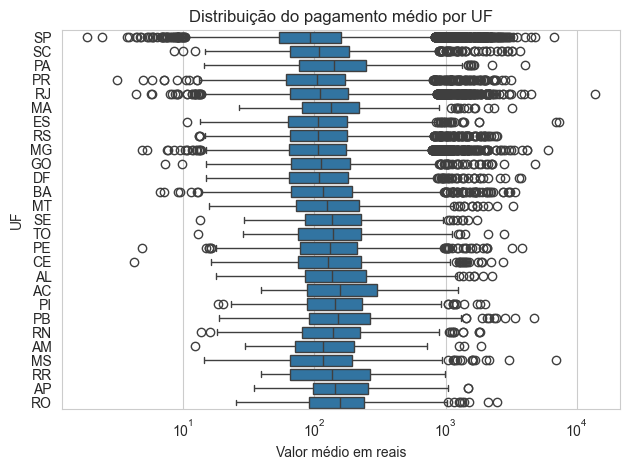

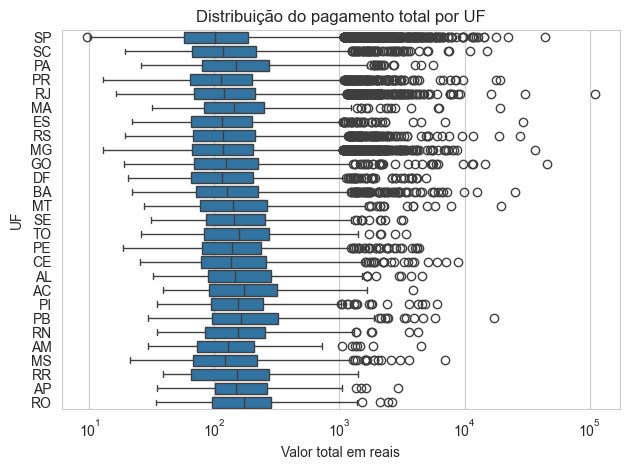

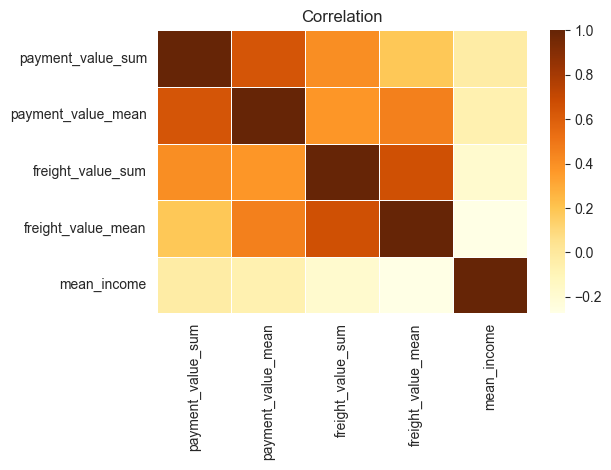

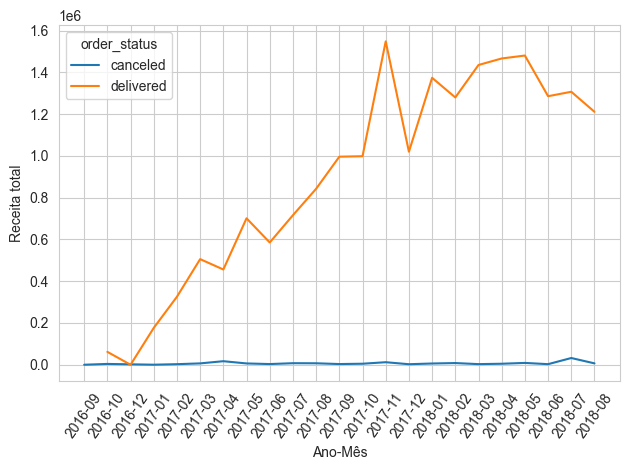

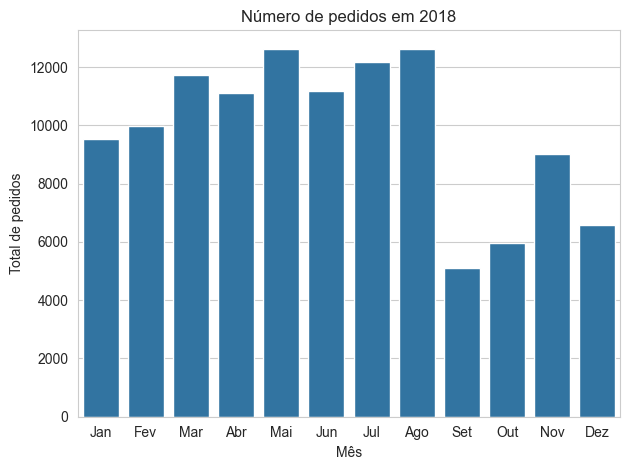

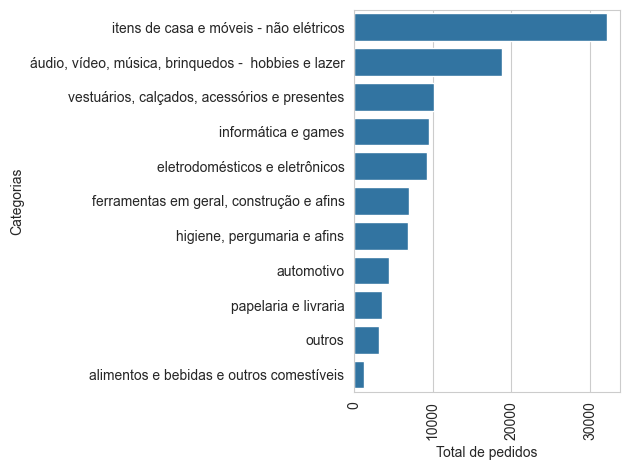

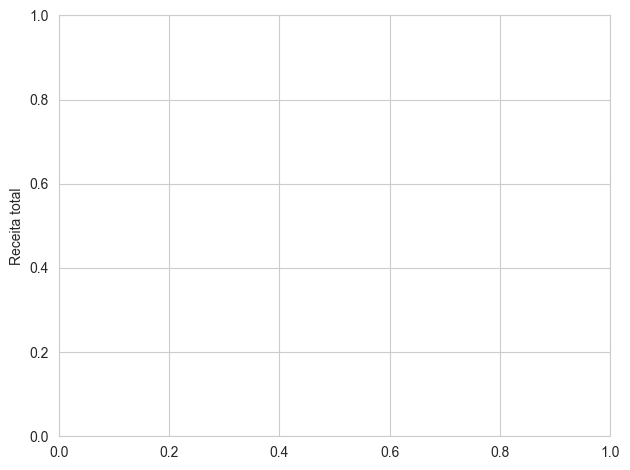

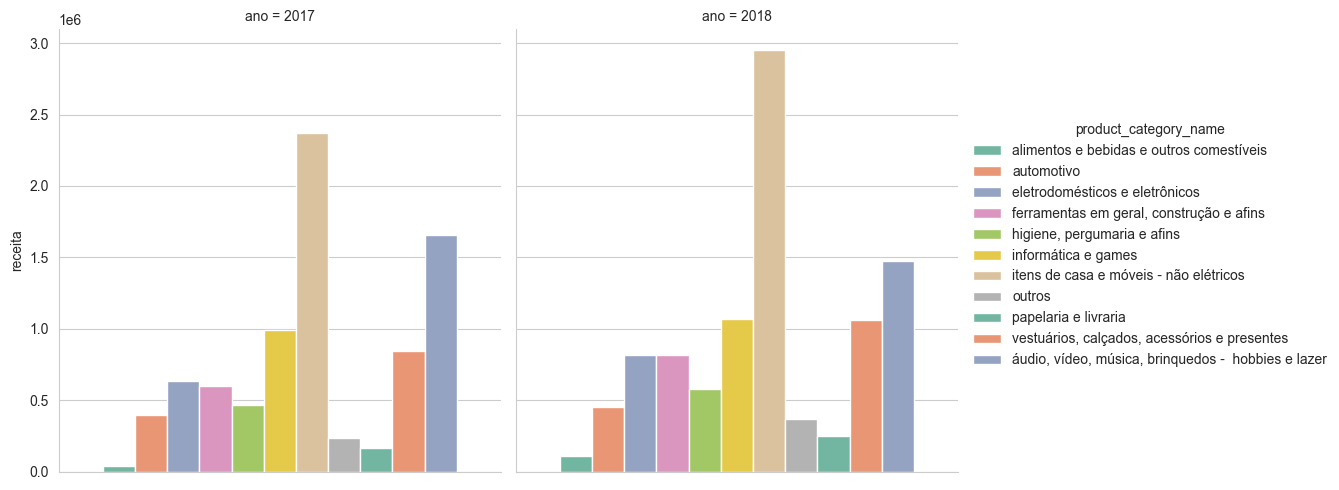

In [12]:

# Dataset analysis
## duplicated
df_cust_group.duplicated().value_counts()
df_cust_group.drop_duplicates(inplace=True)
df_cust_group.duplicated().value_counts()

df_cust_group['customer_unique_id'].duplicated().value_counts() # os duplicados são porque mudaram de UF
df_cust_group['Id_geral']=np.arange(1, df_cust_group.shape[0]+1, step=1)

# Analysing correlation (all orders)
correlation_temp = df[['payment_value', 'price', 'freight_value',
       'product_weight_g', 'product_length_cm', 
       'product_height_cm', 'product_width_cm', 'mean_income']].corr(numeric_only=True)


# Analysis
# Plot
fig, ax = plt.subplots()
sns.set_style("whitegrid")
ax.set_title('Correlation')
sns.heatmap(correlation_temp, cmap=sns.color_palette("YlOrBr", as_cmap=True),  \
linecolor='white', linewidths=0.5)
plt.show()



#  orders analysis by customers (plots)
# Histogram
# Payment value (mean)
f, ax = plt.subplots()
sns.set_style("whitegrid")
sns.histplot(df_cust_group['payment_value_mean'], \
    stat='probability', log_scale=True)
ax.set_ylabel('Proporção')
ax.set_xlabel('Valor médio gasto por consumidor')
plt.show()

# Payment value (sum)
f, ax = plt.subplots()
sns.set_style("whitegrid")
sns.histplot(df_cust_group['payment_value_sum'], \
    stat='probability', log_scale=True)
ax.set_ylabel('Proporção')
ax.set_xlabel('Valor total gasto por consumidor')
plt.show()

# Freight value (sum)
f, ax = plt.subplots()
sns.set_style("whitegrid")
sns.histplot(df_cust_group['freight_value_sum'], \
    stat='probability', log_scale=True)
ax.set_ylabel('Proporção')
ax.set_xlabel('Valor total do frete por consumidor')
plt.show()

# Freight value (mean)
f, ax = plt.subplots()
sns.set_style("whitegrid")
sns.histplot(df_cust_group['freight_value_mean'], \
    stat='probability')
ax.set_ylabel('Proporção')
ax.set_xlabel('Valor médio do frete por consumidor')
plt.show()


# Counts 
# Customers by UF
f, ax = plt.subplots()
sns.set_style("whitegrid")
sns.countplot(data=df_cust_group['short_UF'], \
    order=df_cust_group['short_UF'].value_counts().index, stat='proportion')
ax.set_xlabel('Proporção')
ax.set_ylabel('UF')
ax.set_title('Proporção dos consumidores por UF')
plt.show()

# Boxplots
# Payment (mean)
f, ax = plt.subplots()
sns.set_style("whitegrid")
sns.boxplot(data=df_cust_group, x='payment_value_mean', y='short_UF', log_scale=True)
ax.set_xlabel('Valor médio em reais')
ax.set_ylabel('UF')
ax.set_title('Distribuição do pagamento médio por UF')
plt.show()

# Payment (sum)
f, ax = plt.subplots()
sns.set_style("whitegrid")
sns.boxplot(data=df_cust_group, x='payment_value_sum', y='short_UF', log_scale=True)
ax.set_xlabel('Valor total em reais')
ax.set_ylabel('UF')
ax.set_title('Distribuição do pagamento total por UF')
plt.show()


# Analysing correlation (by customers)

correlation_temp = df_cust_group[['payment_value_sum', 'payment_value_mean',
       'freight_value_sum', 'freight_value_mean', 'customer_state', 'UF',
       'mean_income']].corr(numeric_only=True)

# Correlation
fig, ax = plt.subplots()
ax.set_title('Correlation')
sns.heatmap(correlation_temp, cmap=sns.color_palette("YlOrBr", as_cmap=True),  \
linecolor='white', linewidths=0.5)
plt.show()

# Order analysis

# Plots
f, ax = plt.subplots()
sns.lineplot(data=df_ts_gp.loc[df_ts_gp['order_status'].isin(['delivered','canceled'])].\
    sort_values(by='order_purchase_timestamp'), \
    x = 'order_purchase_timestamp', 
    y = 'payment_value', hue = 'order_status', orient='x')
ax.tick_params(axis='x', rotation=55)
ax.set_ylabel('Receita total')
ax.set_xlabel('Ano-Mês')
plt.show()


count_sells = df['mes'].value_counts()
count_sells.index = count_sells.index.map(month_dict_inv)

f, ax = plt.subplots()
sns.barplot(data=count_sells, order=month_str)
ax.set_xlabel('Mês')
ax.set_ylabel('Total de pedidos')
ax.set_title('Número de pedidos em 2018')
plt.show()

count_category = df['product_category_name'].value_counts()

f, ax = plt.subplots()
sns.set_style("whitegrid")
sns.barplot(data=count_category, order=count_category.index, orient="y")
ax.tick_params(axis='x', labelrotation = 90)
ax.set_ylabel('Categorias')
ax.set_xlabel('Total de pedidos')
plt.show()   

f, ax = plt.subplots()
sns.set_style("whitegrid")
sns.catplot(data=df_category_gp,\
     y='receita', 
     hue='product_category_name', 
     col='ano', 
     col_order=['2017','2018'],
     errorbar=None,
     kind='bar',
     palette='Set2',
     legend_out=True)
ax.set_ylabel('Receita total')
plt.show()

